# Data Profiling 
This section assesses the dataset's structure, quality, and potential issues.

**Data Loading & Date Parsing**

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# load the csv file
df = pd.read_csv('../data/nigeria.csv') 
# Add Country Column
df['Country'] = 'Nigeria'
# create a dat from the year and DOY
df['Date'] = pd.to_datetime(df['YEAR'] * 1000 + df['DOY'], format='%Y%j')
#extracting a month from the year and the DOY
df['Month'] = df['Date'].dt.month
# Check the results
print(df[['YEAR', 'DOY',  'Month']].tail())



      YEAR  DOY  Month
4103  2026   86      3
4104  2026   87      3
4105  2026   88      3
4106  2026   89      3
4107  2026   90      3


**Summary Statistics & Missing-Value Report**

In [24]:
# Check how many rows and features columns we have
print("Data Shape:", df.shape) 
#  Handle NASA Sentinel Values
df.replace(-999, np.nan, inplace=True)
# Duplicate Check
duplicates = df.duplicated().sum()
print(f"Total Duplicate Rows Found: {duplicates}")
if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicates removed.")


Data Shape: (4108, 15)
Total Duplicate Rows Found: 0


**Duplicate check**

0 duplicate rows were detected across all 4,108 observations.

Therefore, No data removal was required showing that each record in the Ethiopia dataset represents a unique observation.

In [25]:

# Generate the 5-number summary (count, mean, std, min, max)
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,26.656928,28.914667,24.886461,4.028206,4.213914,85.237040,2.217135,2.903335,100.827205,18.558505,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,21.120000,25.260000,15.170000,1.160000,0.000000,54.400000,0.740000,1.290000,100.380000,9.430000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.720000,27.920000,24.100000,3.090000,0.330000,83.930000,1.770000,2.370000,100.710000,17.970000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,26.820000,28.990000,25.100000,3.770000,1.840000,86.350000,2.200000,2.810000,100.820000,18.840000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,27.540000,29.910000,25.860000,4.600000,5.200000,88.500000,2.630000,3.390000,100.950000,19.570000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,29.290000,32.880000,27.790000,11.730000,166.100000,93.790000,4.780000,6.000000,101.350000,21.740000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.123335,1.294345,1.396727,1.399169,7.266742,5.446007,0.587191,0.696885,0.165321,1.646313,NaN,3.477046


**Statistical Interpretation of Climate Variables**

 Temperature (T2M): Nigeria is very hot on average at 26.66°C. The temperature is extremely stable (it barely changes), staying between 21.12°C and 29.29°C. Because it stays so hot all the time, the average and the middle number are almost exactly the same.

Daily Temp Change (T2M_RANGE): The difference between day and night temperatures is very small. On average, the temperature only drops by 4.03°C at night. This is much smaller than the big temperature swings we saw in Kenya and Ethiopia.

Rainfall (PRECTOTCORR): Nigeria gets a lot of rain. The average is 4.21 mm per day, but the middle number is 1.84 mm. This means it rains a little bit on most days, but there are some absolutely massive storms that pull the average up. The highest rainfall recorded in a single day was a huge 166.10 mm.

Humidity and Wind (RH2M & WS2M): The air is extremely wet. The average humidity is 85.2%, making it feel very thick and heavy. The wind is fairly calm, averaging 2.22 m/s.

Air Pressure (PS): The pressure is high, averaging 100.83 kPa. This tells us that the location for this data is very close to sea level, unlike the high mountains we saw in the previous countries.

In [26]:
# Check for Missing Values
print("\n--- Missing Value Count ---")
print(df.isna().sum())
missing_values = df.isna().sum()
missing_pct = (missing_values / len(df)) * 100


--- Missing Value Count ---
YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
Date           0
Month          0
dtype: int64


The missing value analysis shows the Ethiopia dataset contains 0% null values across all columns.

What this means for the analysis: Since no columns exceed the 5% threshold. We do not need to fill any gaps. 

**Outlier Detection & Basic Cleaning**



In [27]:
#  Z-Score Calculation
target_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']
z_scores = np.abs(stats.zscore(df[target_cols].dropna()))

# Flagging outliers
outliers_count = (z_scores > 3).sum(axis=0)
print("Outlier counts per column (|Z| > 3):")
print(outliers_count)

Outlier counts per column (|Z| > 3):
[ 10   1  68  75 128   5  10]


**Outlier Detection**

In total we have 297 outliers across the given columns. 

It has been chosen to retain the 297 identified outliers because,

 In a climate dataset, extreme values represent important weather events like storms and heatwaves. most of these extreme events happened in Humidity (128 days) and Rainfall (75 days). This is expected because rain happens in sudden bursts, and these spikes are a real part of the average.

 It is decided to keep all of these numbers to make the climate report will accurately show how extreme the rain and humidity can get in this region.



In [28]:
# Handling Strategy
# Forward-fill for weather variables to maintain time-series continuity
df[target_cols] = df[target_cols].ffill()

# Export Cleaned Data and the data folder is in gitignore
df.to_csv('../data/Nigeria_clean.csv', index=False)

**Time Series Analysis**

***Monthly Temperature Trends (2015–2026)***

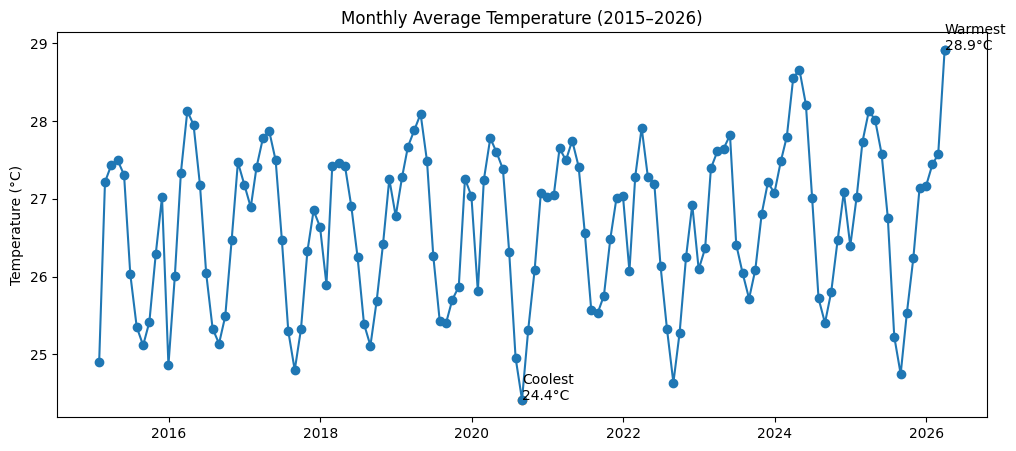

In [29]:
# Resample to monthly averages
monthly_temp = df.set_index('Date').resample('ME')['T2M'].mean().reset_index()

# Find warmest and coolest months
warmest = monthly_temp.loc[monthly_temp['T2M'].idxmax()]
coolest = monthly_temp.loc[monthly_temp['T2M'].idxmin()]

# Plot
plt.figure(figsize=(12,5))
plt.plot(monthly_temp['Date'], monthly_temp['T2M'], marker='o')

# Annotate
plt.scatter(warmest['Date'], warmest['T2M'])
plt.text(warmest['Date'], warmest['T2M'], f"Warmest\n{warmest['T2M']:.1f}°C")

plt.scatter(coolest['Date'], coolest['T2M'])
plt.text(coolest['Date'], coolest['T2M'], f"Coolest\n{coolest['T2M']:.1f}°C")

plt.title('Monthly Average Temperature (2015–2026)')
plt.ylabel('Temperature (°C)')
plt.show()

The line chart shows a steady wave that repeats every year, but notice how high the numbers are! It stays very hot all year round. The hottest month hit 28.9°C and the coolest month dropped to 24.4°C. This means the temperature only shifts by about 4.5°C throughout the whole year. It is a flat, hot line that mostly bounces between 25°C and 28°C for the entire 11 years.

**Monthly Total Precipitation**

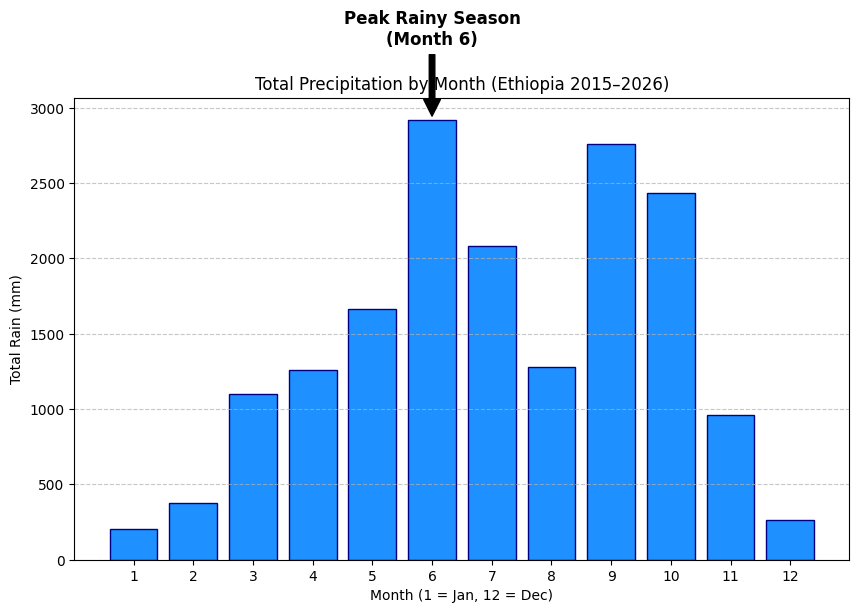

In [ ]:
# 1. Group by Month (1-12) to get the total rain for that month across all years
seasonal_rain = df.groupby('Month')['PRECTOTCORR'].sum().reset_index()

# 2. Find the peak month for annotation
peak_val = seasonal_rain['PRECTOTCORR'].max()
peak_month_num = seasonal_rain.loc[seasonal_rain['PRECTOTCORR'].idxmax(), 'Month']

# 3. Plotting
plt.figure(figsize=(10, 6))
# We use seasonal_rain['Month'] as the X-axis so we get 12 clean bars
plt.bar(seasonal_rain['Month'], seasonal_rain['PRECTOTCORR'], color='dodgerblue', edgecolor='navy')

# 4. Annotation (Identifying the peak)
plt.annotate(f'Peak Rainy Season\n(Month {int(peak_month_num)})', 
             xy=(peak_month_num, peak_val), 
             xytext=(peak_month_num, peak_val + 500),
             ha='center',
             arrowprops=dict(facecolor='black', shrink=0.05),
             fontsize=12, fontweight='bold')

plt.title('Total Precipitation by Month (Nigeria 2015–2026)')
plt.xlabel('Month (1 = Jan, 12 = Dec)')
plt.ylabel('Total Rain (mm)')
plt.xticks(range(1, 13)) # Show every month number
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

The bar chart shows a huge amount of rain. The rainy season starts early in the year and builds up to a massive peak in June (Month 6). Interestingly, there is a small dip in rain during August (Month 8) before it spikes again in September. This quick dry pause in August is a famous weather pattern in West Africa! By December and January, the rain finally stops for a short dry season.

**Correlation & Relationship Analysis**

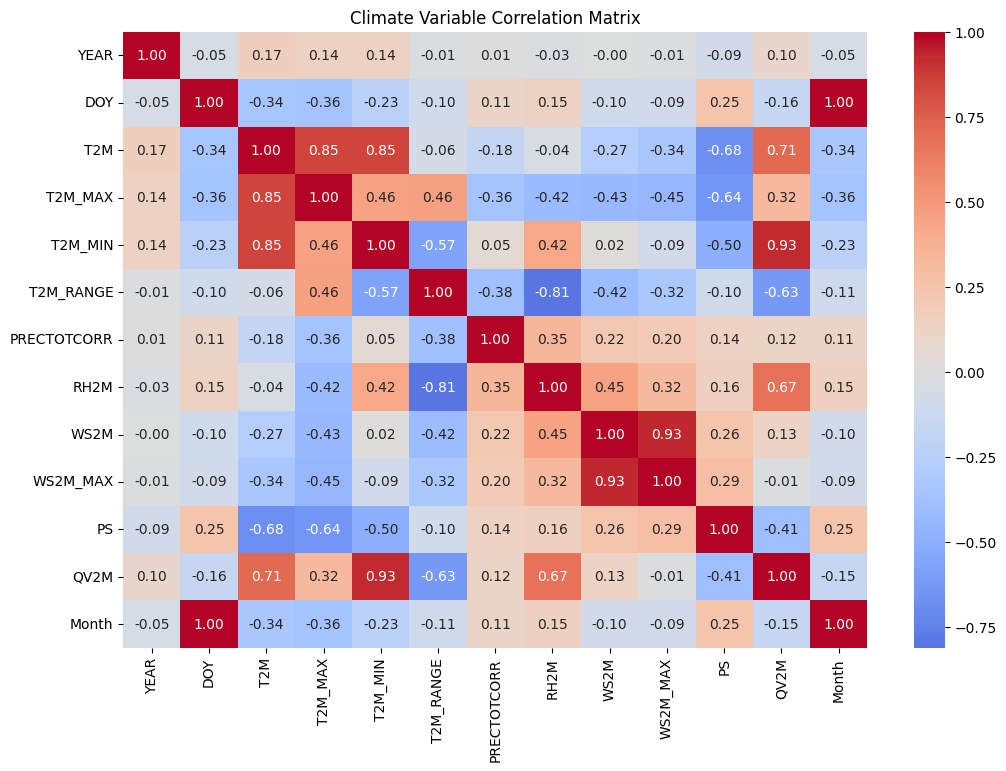

In [31]:
# Heatmap of correlations
plt.figure(figsize=(12, 8))
# We only select numeric columns to avoid errors with the Date or Country strings
numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()

sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Climate Variable Correlation Matrix')
plt.show()

Based on the heatmap, here are the three most significant relationships in the dataset:

Wind Speed (WS2M vs. WS2M_MAX): 0.93
Just like the other countries, this is a very strong link. On days when the normal wind is blowing fast, the strongest gusts are also very fast.

Temp Change vs. Humidity (T2M_RANGE vs. RH2M): -0.81
This is a strong backwards link. It shows that on the rare days when the air is dry (low humidity), the temperature drops more at night. When it is super humid, the temperature barely changes from day to night.

Temp vs. Water in the Air (T2M vs. QV2M): 0.71
This shows that as the temperature goes up, the actual physical amount of water floating in the air goes up too. This is what creates that very thick, sticky, tropical heat.

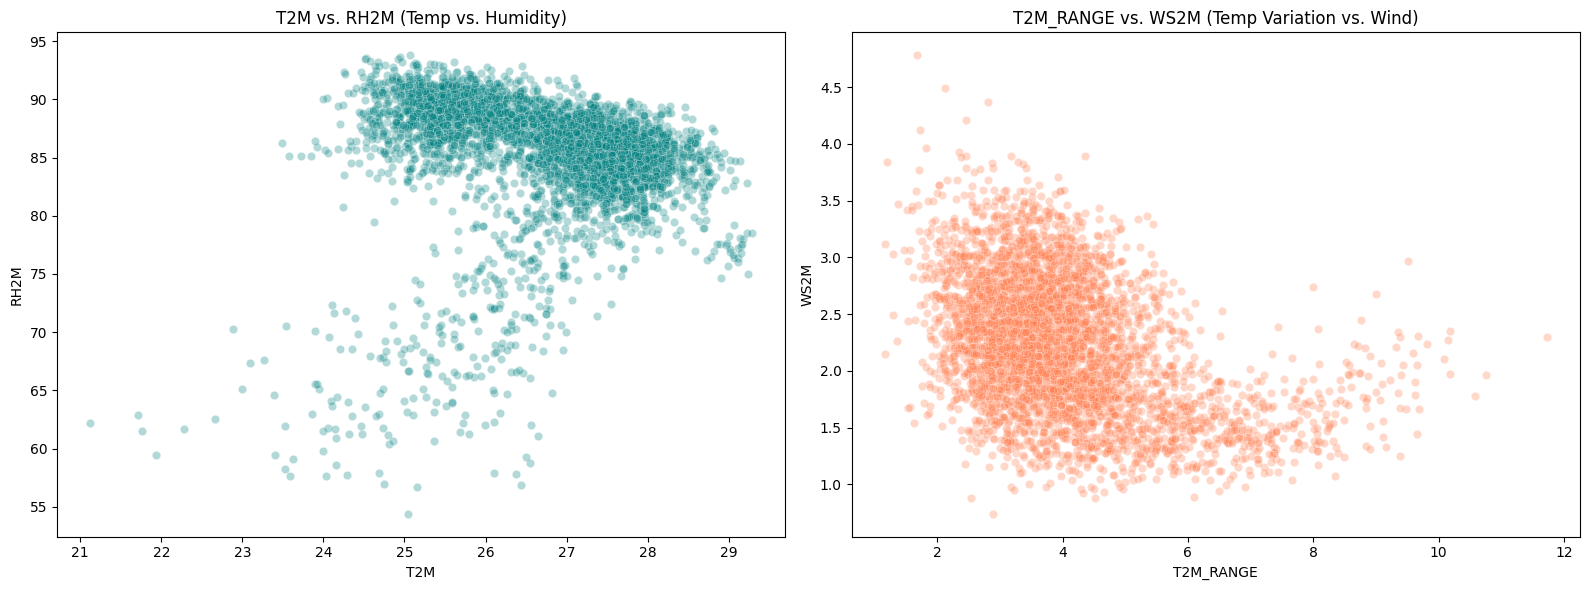

In [32]:
# Scatter plots for specific relationships
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Temperature vs Relative Humidity
sns.scatterplot(data=df, x='T2M', y='RH2M', alpha=0.3, ax=ax1, color='teal')
ax1.set_title('T2M vs. RH2M (Temp vs. Humidity)')

# Plot 2: Diurnal Range vs Wind Speed
sns.scatterplot(data=df, x='T2M_RANGE', y='WS2M', alpha=0.3, ax=ax2, color='coral')
ax2.set_title('T2M_RANGE vs. WS2M (Temp Variation vs. Wind)')

plt.tight_layout()
plt.show()

Temp vs. Humidity (Left): This chart is a giant cloud squished at the very top. It shows that no matter what the temperature is, the humidity is almost always stuck very high (between 80% and 95%).

Temp Change vs. Wind Speed (Right): This is a messy cloud, which means there isn't a perfect rule here. Most days have a very small temperature change (between 2°C and 6°C) and calm winds, which groups all the dots on the left side.

**Distribution Analysis**

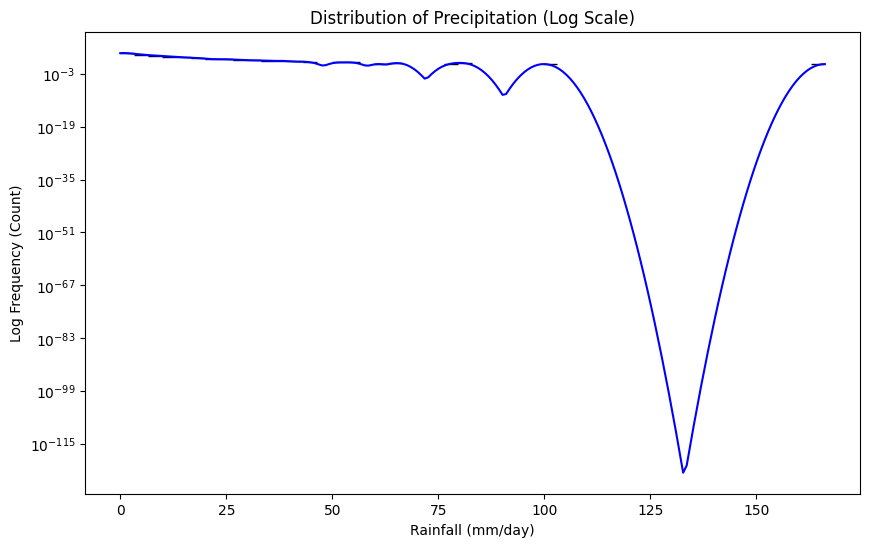

In [33]:
#  Distribution of Rainfall
plt.figure(figsize=(10, 6))
# log_scale=(False, True) means the counts (Y-axis) are log-transformed
sns.histplot(df['PRECTOTCORR'], bins=50, kde=True, color='blue', log_scale=(False, True))

plt.title('Distribution of Precipitation (Log Scale)')
plt.xlabel('Rainfall (mm/day)')
plt.ylabel('Log Frequency (Count)')
plt.show()

This chart shows just how extreme tropical storms can be. While most days have just a little bit of rain, the line stretches incredibly far to the right. This proves that Nigeria gets hit by rare, massive storms that can dump over 160 mm of water in just one single day.

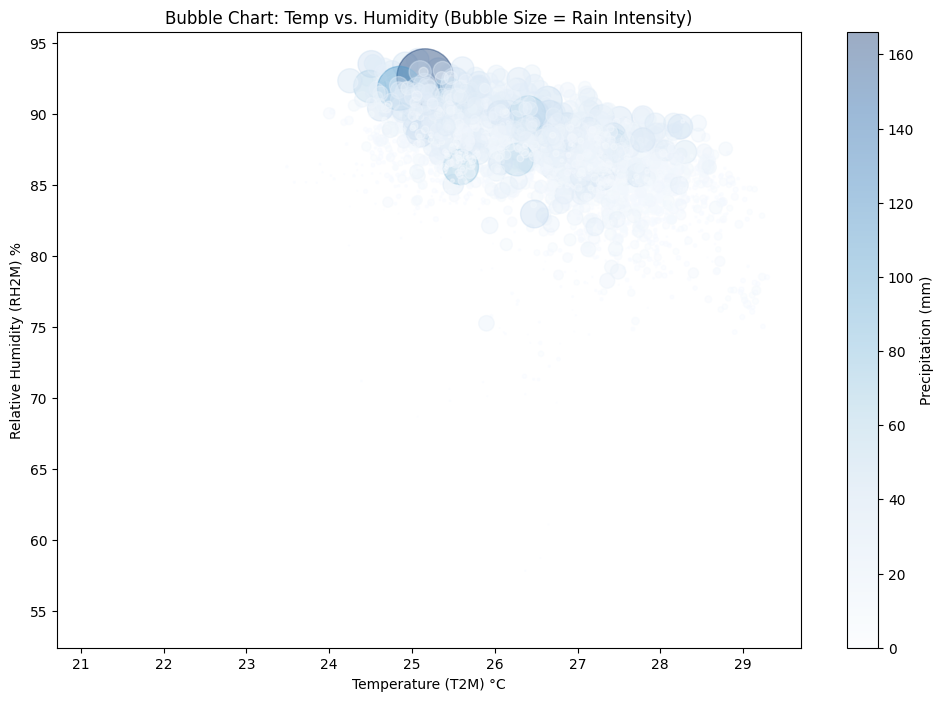

In [34]:
# Bubble Chart: T2M vs. RH2M (Size = PRECTOTCORR)
plt.figure(figsize=(12, 8))

# We multiply PRECTOTCORR by 10 to make the bubbles large enough to see
plt.scatter(df['T2M'], df['RH2M'], 
            s=df['PRECTOTCORR'] * 10, 
            alpha=0.4, 
            c=df['PRECTOTCORR'], 
            cmap='Blues')

plt.colorbar(label='Precipitation (mm)')
plt.title('Bubble Chart: Temp vs. Humidity (Bubble Size = Rain Intensity)')
plt.xlabel('Temperature (T2M) °C')
plt.ylabel('Relative Humidity (RH2M) %')
plt.show()

This chart tells us exactly when those huge storms happen. The biggest, darkest bubbles (the heaviest rain) are all squished at the very top left. This means the biggest storms happen when the air is unbelievably wet (humidity around 90%) and the temperature cools down just a little bit to around 25°C. When it gets hotter than 27°C, the bubbles disappear, meaning the heavy rain stops.